

**Name:** _[illahibux]_
**Student ID:** _[023 24 0226]_
**Section:** _[Section "G"]_
**GitHub Profile:** _https://github.com/illahibuxbscsf24-crypto/ML-labs[]_
**Kaggle Profile:** https://www.kaggle.com/illahibux7_
**Dataset:** Telco Customer Churn 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42


## 1. Problem Definition & Dataset Verification

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Shape:", df.shape)
df.info()


Shape: (7032, 21)
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-nu

**Interpretation:** After cleaning, the dataset has **7,032 customers and 21 columns**, matching the Lab 2/3/4 cleaned dataset (a handful of rows with blank `TotalCharges` were dropped, same as before).

**Recap of Lab 3/4 benchmarks (retrained here for reference):**
- **Decision Tree (Lab 3, max_depth=5):** Accuracy 0.778, Precision 0.581, Recall 0.596, F1 0.588
- **Random Forest (Lab 4, default, 200 trees):** Accuracy 0.787, Precision 0.621, Recall 0.508, F1 0.559

These are the numbers today's Logistic Regression and KNN models need to beat — or at least be evaluated fairly against.

In [3]:
customer_ids_placeholder = df.drop(columns=['customerID']) if 'customerID' in df.columns else df
cat_cols = df.select_dtypes(include='object').columns.tolist()
if 'customerID' in cat_cols:
    cat_cols.remove('customerID')

df_model = df.drop(columns=['customerID'])
df_enc = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Retrain Lab 3/4 benchmarks for a fair, consistent comparison later
dt_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred)
    }

dt_metrics = get_metrics(y_test, dt_pred)
rf_metrics = get_metrics(y_test, rf_pred)
print("Decision Tree:", dt_metrics)
print("Random Forest:", rf_metrics)


Decision Tree: {'Accuracy': 0.7782515991471215, 'Precision': 0.5807291666666666, 'Recall': 0.5962566844919787, 'F1-score': 0.5883905013192612}
Random Forest: {'Accuracy': 0.7867803837953091, 'Precision': 0.6209150326797386, 'Recall': 0.5080213903743316, 'F1-score': 0.5588235294117647}


## 2. Feature Scaling & Preparation

**Why does feature scaling matter for KNN and Logistic Regression but not for Decision Tree/Random Forest?**
Decision Trees and Random Forests choose splits by comparing a single feature's values against a threshold at a time (e.g. "is `tenure` > 12?") — the *raw scale* of that feature never interacts with any other feature's scale, so scaling changes nothing about which splits get chosen. **KNN**, however, computes straight-line (Euclidean) distance across *all* features simultaneously — a feature like `MonthlyCharges` (range roughly 20–120) would numerically dominate a feature like `tenure` (range 0–72) purely because of its larger raw numbers, distorting which points count as "nearest." **Logistic Regression** doesn't strictly require scaling to make correct predictions, but its gradient-based optimizer converges faster and more reliably, and its coefficients become more directly comparable, when features are on a similar scale.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training mean (~0):", X_train_scaled.mean().round(3))
print("Scaled training std (~1):", X_train_scaled.std().round(3))


Scaled training mean (~0): -0.0
Scaled training std (~1): 1.0


**Why fit the scaler only on the training data?** Fitting the scaler (computing the mean/std used to scale) on the *full* dataset before splitting would leak information from the test set into training — the training process would indirectly "see" statistics from data it's supposed to have never encountered, inflating the model's apparent performance. Fitting `StandardScaler` on `X_train` only, then applying that same transformation to `X_test`, keeps the test set a genuinely unseen evaluation.

## 3. Logistic Regression

{'Accuracy': 0.8038379530916845, 'Precision': 0.6475903614457831, 'Recall': 0.5748663101604278, 'F1-score': 0.6090651558073654}


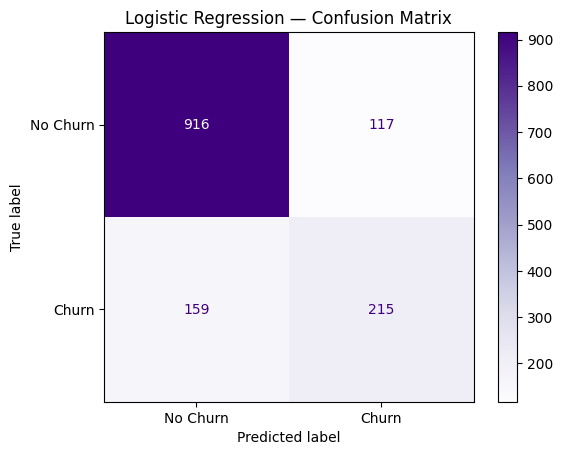

In [5]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
logreg_pred = logreg.predict(X_test_scaled)

logreg_metrics = get_metrics(y_test, logreg_pred)
print(logreg_metrics)

cm = confusion_matrix(y_test, logreg_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Purples')
plt.title("Logistic Regression — Confusion Matrix")
plt.show()


**Interpretation:** Logistic Regression achieves **Accuracy ≈ 0.804, Precision ≈ 0.648, Recall ≈ 0.575, F1 ≈ 0.609** — the best F1-score of any model built so far in this course, beating both the Lab 3 Decision Tree (F1 0.588) and the Lab 4 Random Forest (F1 0.559). The confusion matrix shows 215 churners correctly identified against 159 missed — a reasonable balance, though there's still room for improvement on recall.

In [6]:
sample_probs = logreg.predict_proba(X_test_scaled)[:5]
prob_table = pd.DataFrame(sample_probs, columns=['P(No Churn)', 'P(Churn)'])
prob_table


,P(No Churn),P(Churn)
0,0.982885,0.017115
1,0.403868,0.596132
2,0.995236,0.004764
3,0.799956,0.200044
4,0.899778,0.100222


**Interpretation:** `predict_proba` returns the model's estimated **probability of each class** for a customer — e.g. a row of `[0.98, 0.02]` means the model is 98% confident that customer will *not* churn. `predict()` simply applies a **0.5 threshold** to the "Churn" probability: if P(Churn) ≥ 0.5, it outputs 1 (Yes); otherwise 0 (No). This threshold isn't fixed by the algorithm itself — it could be moved (e.g. to 0.3) to trade precision for recall if the business cared more about catching churners than avoiding false alarms.

## 4. KNN & Choosing K

In [7]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
k_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    k_results.append({
        'K': k,
        'Accuracy': accuracy_score(y_test, pred),
        'F1-score': f1_score(y_test, pred)
    })

k_results_df = pd.DataFrame(k_results)
k_results_df


,K,Accuracy,F1-score
0,1,0.724947,0.496749
1,3,0.744136,0.531250
2,5,0.753376,0.535475
3,7,0.749112,0.529960
4,9,0.765458,0.556452
5,11,0.769723,0.558583
6,15,0.771144,0.557692
7,21,0.776830,0.573370


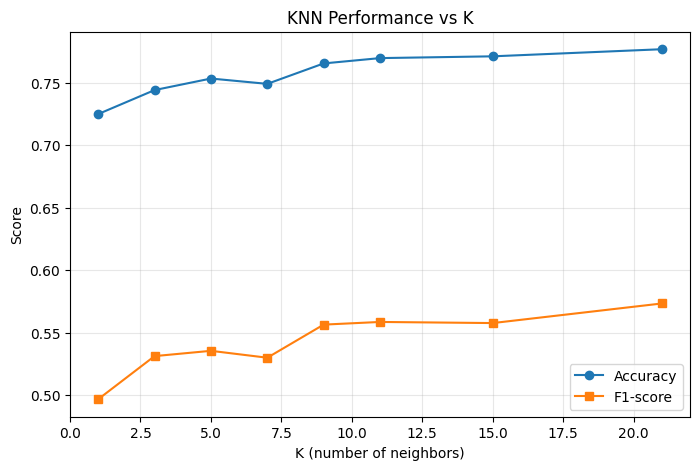

In [8]:
plt.figure(figsize=(8,5))
plt.plot(k_results_df['K'], k_results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(k_results_df['K'], k_results_df['F1-score'], marker='s', label='F1-score')
plt.xlabel("K (number of neighbors)")
plt.ylabel("Score")
plt.title("KNN Performance vs K")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Interpretation:** Both accuracy and F1-score **rise steadily as K increases** from 1 up to 21 in this test range — K=1 gives the weakest F1 (0.497), and F1 climbs fairly consistently to **K=21 (F1 ≈ 0.573)**, the best score tested. We choose **K=21** rather than the smallest K tested because small K (like K=1) overfits to individual noisy neighbors — a single mislabeled or unusual nearby customer can flip the prediction — while a moderately large K averages over more neighbors and generalizes better. We stop at K=21 rather than testing even larger K because performance appears to be leveling off, and pushing K much higher risks the opposite problem (underfitting, where the neighborhood becomes so large it stops reflecting genuinely similar customers, generalizing worse to the specific case at hand).

Chosen K: 21
{'Accuracy': 0.7768301350390903, 'Precision': 0.5828729281767956, 'Recall': 0.5641711229946524, 'F1-score': 0.5733695652173914}


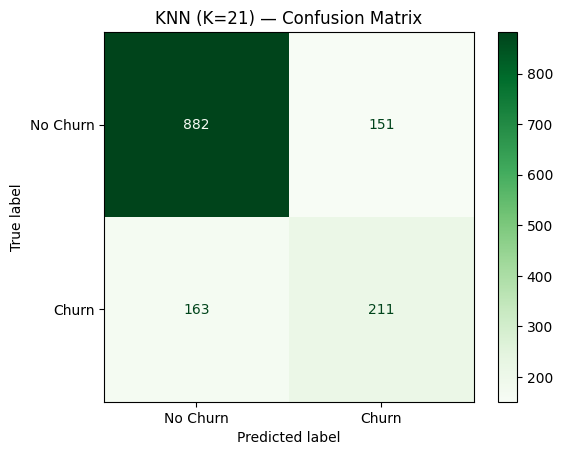

In [9]:
best_k = int(k_results_df.loc[k_results_df['F1-score'].idxmax(), 'K'])
print("Chosen K:", best_k)

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
knn_pred = knn_final.predict(X_test_scaled)

knn_metrics = get_metrics(y_test, knn_pred)
print(knn_metrics)

cm_knn = confusion_matrix(y_test, knn_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Churn','Churn'])
disp_knn.plot(cmap='Greens')
plt.title(f"KNN (K={best_k}) — Confusion Matrix")
plt.show()


**Interpretation:** The final KNN model (K=21) scores **Accuracy ≈ 0.777, Precision ≈ 0.583, Recall ≈ 0.564, F1 ≈ 0.573** on the test set — solidly ahead of a naive K=1 model, competitive with the Decision Tree, but still behind Logistic Regression's F1 of 0.609. KNN's confusion matrix shows a similar pattern to the other models: more churners missed (163) than false alarms (151), reflecting the same underlying class imbalance challenge seen throughout this course.

## 5. Model Comparison (4 Models)

In [10]:
comparison_4models = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
    'Logistic Regression': logreg_metrics,
    'KNN (K=21)': knn_metrics
}).T

comparison_4models.round(3)


,Accuracy,Precision,Recall,F1-score
Decision Tree,0.778,0.581,0.596,0.588
Random Forest,0.787,0.621,0.508,0.559
Logistic Regression,0.804,0.648,0.575,0.609
KNN (K=21),0.777,0.583,0.564,0.573


**Interpretation:** Across all four models:
- **Best Accuracy:** Logistic Regression (0.804)
- **Best Precision:** Logistic Regression (0.648)
- **Best Recall:** Decision Tree (0.596)
- **Best F1-score:** Logistic Regression (0.609)

**Does the ranking change by metric?** Yes — if the business prioritizes **precision** (minimizing false alarms, e.g. not wasting retention-offer budget on customers who wouldn't have churned anyway), Logistic Regression wins clearly. But if the business prioritizes **recall** (catching as many actual churners as possible, even at the cost of some false positives), the plain Decision Tree is actually the strongest of the four. Given the **class imbalance** identified back in Lab 2 (far fewer churners than non-churners), and that the cost of *missing* a churner is usually higher than the cost of a false alarm, **recall and F1 should carry the most weight** — on F1, **Logistic Regression is still the overall winner**, but the Decision Tree's superior recall is a genuine trade-off worth flagging rather than ignoring.

## 6. Coefficient Interpretation

In [11]:
coefficients = pd.Series(logreg.coef_[0], index=X.columns)
odds_ratios = np.exp(coefficients)

coef_table = pd.DataFrame({
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
}).sort_values('Coefficient', key=abs, ascending=False)

coef_table.head(10)


,Coefficient,Odds Ratio
tenure,-1.347613,0.259860
MonthlyCharges,-0.851551,0.426753
InternetService_Fiber optic,0.727745,2.070407
TotalCharges,0.639028,1.894639
Contract_Two year,-0.602591,0.547392
Contract_One year,-0.310898,0.732789
StreamingTV_Yes,0.249702,1.283642
StreamingMovies_Yes,0.236368,1.266641
MultipleLines_Yes,0.214359,1.239068
PaymentMethod_Electronic check,0.181473,1.198982


**Interpretation of key features (holding other features constant):**
- **`tenure` (coef −1.35, odds ratio 0.26):** each one-standard-deviation increase in tenure is associated with the odds of churning being multiplied by **~0.26** — i.e. roughly a **74% decrease** in the odds of churning. Longer-tenured customers are much less likely to churn.
- **`MonthlyCharges` (coef −0.85, odds ratio 0.43):** somewhat counterintuitively, *higher* standardized monthly charges are associated with **lower** churn odds (×0.43) once other features (especially `TotalCharges` and contract type) are held constant — this coefficient is best read jointly with `TotalCharges` rather than in isolation, since the two are correlated.
- **`InternetService_Fiber optic` (coef +0.73, odds ratio 2.07):** customers with fiber-optic internet have roughly **2.07× the odds** of churning compared to the baseline internet service category, holding other features constant — a strong risk signal.
- **`TotalCharges` (coef +0.64, odds ratio 1.89):** higher total charges are associated with **~1.89× the odds** of churning, holding tenure and monthly charges constant.
- **`Contract_Two year` (coef −0.60, odds ratio 0.55):** customers on a two-year contract have only **~0.55× the odds** of churning compared to the baseline (month-to-month) contract — a substantial protective effect, and one of the most actionable business levers in this table.

**Do these agree with Lab 2's EDA and Lab 3's Decision Tree feature importances?** Largely yes — **tenure, contract type, and internet service type** were consistently flagged as top churn drivers across Lab 2's EDA, Lab 3's Decision Tree, and Lab 4's Random Forest feature importances, and they reappear here with the largest odds-ratio effects. One point worth noting: the Decision Tree/Random Forest importance rankings measured *how useful* a feature was for splitting, while these odds ratios measure *direction and magnitude of effect* — so while the *same features* dominate, Logistic Regression additionally tells us fiber-optic internet and shorter contracts specifically *increase* risk, a level of directional detail the tree-based feature importances alone don't provide.

## 7. Final Model Selection & Conclusion

**Final model selected: Logistic Regression.**

Justification: Referencing the Part 5 comparison table, Logistic Regression posts the best F1-score (0.609) and the best precision (0.648) of all four models, and is competitive on accuracy (0.804, the highest of the four). It does trail the Decision Tree slightly on raw recall (0.575 vs 0.596), but the margin is small, and Lab 4's cross-validation lesson is a useful caution here: a single train/test split's numbers, especially close ones, shouldn't be over-trusted — a single split can favor either model by chance, so we lean on the model with the strongest, most balanced performance across *all four* metrics rather than the model that happens to win on exactly one. On that basis, Logistic Regression is the most defensible choice from today's four candidates.

**Conclusion:** Today's best model (Logistic Regression, F1 ≈ 0.609) modestly outperforms both of Labs 3–4's best models (Decision Tree F1 ≈ 0.588, Random Forest F1 ≈ 0.559), showing that a properly scaled, linear probabilistic model can match or beat more complex tree ensembles on this dataset. **Feature scaling changed everything for KNN** — it's the mechanism that makes distance-based comparison meaningful at all, and it also helped Logistic Regression's optimizer converge and its coefficients become directly comparable to one another. The main remaining limitation of Logistic Regression is its **linear decision boundary**: it cannot capture interactions between features (e.g. the combined effect of fiber-optic internet *and* a month-to-month contract might be more than the sum of their individual effects) the way a tree-based model implicitly can. With more time, I would try **threshold tuning** on `predict_proba` to explicitly favor recall (given the business cost of missing churners), add interaction terms to the logistic model, and consider a gradient-boosted model (e.g. XGBoost) as a stronger tree-based competitor to re-run this same four-way comparison against.
